# Sliced Latin Hypercube Design

A Latin Hypercube Design (LHD) is a space-filling sampling plan where each input dimension is divided into $n$ equal intervals with exactly one point per interval, ensuring perfect marginal uniformity in every dimension.

**Sliced LHDs** partition the $n = t \cdot m$ runs into $t$ equally-sized slices of $m$ points each, such that both the full design and every individual slice are valid LHDs. This makes them useful for computer experiments with a qualitative factor (e.g. code version, material type), or for sequential batches where each batch of $m$ runs must be space-filling on its own.

`maximinSLHD` minimises the average reciprocal distance criterion $\phi$ (lower = better spread) using simulated annealing. Two orthogonal choices are available:

- **Grid vs. scrambled** — grid places points at regular midpoints $(i - 0.5)/n$ within their stratum; scrambled applies random within-stratum jitter, breaking the lattice structure and improving multi-dimensional coverage
- **Optimized vs. random** — the optimized construction (`maximinSLHD`) uses simulated annealing to rearrange column permutations; the random baseline (`random_slhd`) uses an independent random construction with no further optimisation

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()
if (_root / "gethypercube").is_dir():
    pass
elif (_root.parent / "gethypercube").is_dir():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

%load_ext autoreload
%autoreload 2

from gethypercube import maximinSLHD, ks_test_uniform, lhs_degree
from gethypercube.sliced_lhd.construction import random_slhd
from gethypercube.sliced_lhd.objective import compute_phi
from gethypercube.sliced_lhd import is_valid_slhd

plt.rcParams["figure.facecolor"] = "white"

In [2]:
# ── Design helpers ─────────────────────────────────────────────────────────────

from dataclasses import dataclass, field


@dataclass
class MockSLHDResult:
    """Wraps a random_slhd construction to match the SLHDResult API."""
    design: np.ndarray
    std_design: np.ndarray
    measure: float
    n_slices: int
    n_per_slice: int
    n_dims: int
    temp0: float = 0.0


def build_random_result(t, m, k, seed=42, scramble=True):
    """Unoptimized random SLHD: random_slhd integer construction → continuous design."""
    rng = np.random.default_rng(seed)
    D_int = random_slhd(t=t, m=m, k=k, rng=rng)
    n = t * m
    rng2 = np.random.default_rng(seed ^ 0xCAFE)
    D_cont = (D_int - 1 + rng2.random((n, k))) / n if scramble else (D_int - 0.5) / n
    slice_ids = np.repeat(np.arange(1, t + 1), m).astype(float)
    std_design = np.column_stack([slice_ids, D_cont])
    phi = compute_phi(D_int.astype(float), r=15)
    return MockSLHDResult(design=D_int, std_design=std_design, measure=phi,
                          n_slices=t, n_per_slice=m, n_dims=k)


def design_vars(result):
    """Continuous design variables (n, k) and integer slice IDs (1-based)."""
    D = result.std_design
    if result.n_slices > 1:
        return D[:, 1:], D[:, 0].astype(int)
    return D, np.ones(len(D), dtype=int)


def raw_integer_vars(result):
    """Integer design variables, slice column removed if present."""
    D = result.design
    if D.shape[1] > result.n_dims:
        return D[:, 1:]
    return D


# ── Discrepancy ────────────────────────────────────────────────────────────────

def star_discrepancy(X):
    n = len(X)
    worst = 0.0
    for i in range(n):
        empirical = np.mean(np.all(X <= X[i], axis=1))
        expected = np.prod(X[i])
        worst = max(worst, abs(empirical - expected))
    return worst


def centered_discrepancy(X):
    n, k = X.shape
    z = X - 0.5
    t1 = (13.0 / 12.0) ** k
    t2 = (2.0 / n) * np.sum(np.prod(1.0 + 0.5 * np.abs(z) - 0.5 * z**2, axis=1))
    zi = z[:, None, :]
    zl = z[None, :, :]
    t3 = (1.0 / n**2) * np.sum(
        np.prod(1.0 + 0.5 * np.abs(zi) + 0.5 * np.abs(zl) - 0.5 * np.abs(zi - zl), axis=2)
    )
    return float(np.sqrt(t1 - t2 + t3))


# ── Statistics ─────────────────────────────────────────────────────────────────

def slhd_stats(result):
    """Compute stats for an SLHDResult: phi, LHS degree, KS (full + per-slice), discrepancies."""
    X, slice_ids = design_vars(result)
    t, m = result.n_slices, result.n_per_slice

    ks_full = ks_test_uniform(X)
    ks_full_stats = [s for s, _ in ks_full]

    ks_slice_all = []
    for s in range(1, t + 1):
        xs = X[slice_ids == s]
        ks_slice_all.extend(v for v, _ in ks_test_uniform(xs))

    return {
        "phi":           result.measure,
        "valid":         is_valid_slhd(raw_integer_vars(result), t=t, m=m),
        "lhs_degree":    lhs_degree(X),
        "ks_full_mean":  float(np.mean(ks_full_stats)),
        "ks_full_max":   float(max(ks_full_stats)),
        "ks_slice_mean": float(np.mean(ks_slice_all)),
        "ks_slice_max":  float(max(ks_slice_all)),
        "d_star":        star_discrepancy(X),
        "cd":            centered_discrepancy(X),
    }


def print_slhd_stats(result, label=""):
    s = slhd_stats(result)
    n = result.n_slices * result.n_per_slice
    print(f"{label}  n={n}  t={result.n_slices}  k={result.n_dims}")
    print(f"  valid={s['valid']}  phi={s['phi']:.4f}  LHS_degree={s['lhs_degree']:.4f}")
    print(f"  KS_full  mean={s['ks_full_mean']:.4f}  max={s['ks_full_max']:.4f}")
    print(f"  KS_slice mean={s['ks_slice_mean']:.4f}  max={s['ks_slice_max']:.4f}")
    print(f"  D*={s['d_star']:.4f}  CD={s['cd']:.4f}")


# ── Scatter plot ───────────────────────────────────────────────────────────────

def plot_scatter_grid(options, title=""):
    """2×2 scatter grid for k=2 sliced designs. options: list of dicts with 'label', 'result'."""
    n_opts = len(options)
    n_cols = min(2, n_opts)
    n_rows = (n_opts + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)
    axes = axes.flatten()
    for idx, opt in enumerate(options):
        ax = axes[idx]
        result = opt["result"]
        X, slice_ids = design_vars(result)
        t = result.n_slices
        colors = plt.cm.Set1(np.linspace(0, 0.8, t))
        for s in range(1, t + 1):
            mask = slice_ids == s
            ax.scatter(X[mask, 0], X[mask, 1], s=55, c=[colors[s - 1]],
                       edgecolors="white", linewidths=1.0, label=f"Slice {s}", zorder=3)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_aspect("equal")
        ax.legend(loc="upper left", fontsize=7)
        ax.set_title(f"{opt['label']}\nphi = {result.measure:.4f}")
        ax.grid(True, alpha=0.2)
    for idx in range(n_opts, len(axes)):
        axes[idx].set_visible(False)
    if title:
        fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# ── Marginal uniformity ────────────────────────────────────────────────────────

def plot_marginal_uniformity_combined(options, k, title="Marginal uniformity — full design"):
    """Overlay all options' full-design empirical CDFs (one subplot per dimension)."""
    _auto = [
        ("black",   ":",  1.5),
        ("black",   "-.", 1.2),
        ("black",   "--", 2.0),
        ("black",   "-",  2.0),
        ("#e05252", "-",  1.8),
    ]
    fig, ax = plt.subplots(1, k, figsize=(3.5 * k, 3.5), sharey=True)
    ax = np.atleast_1d(ax)
    xx = np.linspace(0, 1, 100)
    for oi, opt in enumerate(options):
        X, _ = design_vars(opt["result"])
        n = len(X)
        color = opt.get("color", _auto[oi][0])
        ls    = opt.get("ls",    _auto[oi][1])
        lw    = opt.get("lw",    _auto[oi][2])
        for j in range(k):
            sorted_vals = np.sort(X[:, j])
            emp_y = np.arange(1, n + 1, dtype=float) / n
            ax[j].plot(sorted_vals, emp_y, color=color, lw=lw, ls=ls,
                       label=opt["label"] if j == 0 else None)
    for j in range(k):
        ax[j].plot(xx, xx, color="#9ca3af", lw=1.2, ls="--",
                   label="U(0,1)" if j == 0 else None)
        ax[j].set_xlim(-0.02, 1.02)
        ax[j].set_ylim(-0.02, 1.02)
        ax[j].set_aspect("equal")
        ax[j].grid(True, alpha=0.3)
        ax[j].set_title(f"$x_{{{j + 1}}}$", fontsize=10)
        ax[j].set_xlabel("$x$")
    ax[0].set_ylabel("CDF")
    ax[0].legend(loc="lower right", fontsize=7)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_per_slice_uniformity(result, title_prefix=""):
    """Per-slice marginal uniformity: (t x k) grid of empirical vs U(0,1) CDFs."""
    X, slice_ids = design_vars(result)
    t, m, k = result.n_slices, result.n_per_slice, result.n_dims
    fig, ax = plt.subplots(t, k, figsize=(3 * k, 2.5 * t),
                           sharex=True, sharey=True, squeeze=False)
    xx = np.linspace(0, 1, 100)
    for s in range(1, t + 1):
        xs = X[slice_ids == s]
        ks = ks_test_uniform(xs)
        for j in range(k):
            a = ax[s - 1, j]
            sorted_vals = np.sort(xs[:, j])
            emp_y = np.arange(1, m + 1, dtype=float) / m
            a.plot(sorted_vals, emp_y, color="#2563eb", lw=1.8)
            a.plot(xx, xx, color="#9ca3af", lw=1.2, ls="--")
            a.set_xlim(-0.02, 1.02)
            a.set_ylim(-0.02, 1.02)
            a.set_aspect("equal")
            a.grid(True, alpha=0.3)
            a.set_title(f"Slice {s} $\\cdot$ $x_{{{j + 1}}}$\nKS={ks[j][0]:.3f}", fontsize=8)
            if j == 0:
                a.set_ylabel("CDF")
    plt.setp(ax[-1, :], xlabel="$x$")
    fig.suptitle(f"{title_prefix}Per-slice marginal uniformity", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

### Small Design — Visualizing Slice Structure

Below we build four $n=40$ designs ($t=4$ slices, $m=10$ points per slice, $k=2$ dimensions). Each slice is shown in a distinct color; a well-optimized SLHD has slices that individually tile $[0,1]^2$ while jointly forming a single space-filling LHD.

| Configuration | Construction |
|---|---|
| **random** | `random_slhd`: independent random permutations, no optimization |
| **grid** | `random_slhd` with midpoint placement, no optimization |
| **grid + optimized** | `maximinSLHD(scramble=False)`: midpoints + simulated annealing |
| **scrambled + optimized** | `maximinSLHD(scramble=True)`: jittered + simulated annealing |

In [3]:
t_small, m_small, k_small = 4, 10, 2

result_rand          = build_random_result(t_small, m_small, k_small, seed=42, scramble=True)
result_rand_grid     = build_random_result(t_small, m_small, k_small, seed=42, scramble=False)
result_grid_opt      = maximinSLHD(t=t_small, m=m_small, k=k_small, random_state=42,
                                   scramble=False, total_iter=100_000)
result_scram_opt     = maximinSLHD(t=t_small, m=m_small, k=k_small, random_state=42,
                                   scramble=True, total_iter=100_000)

small_options = [
    {"label": "random",               "result": result_rand,      "color": "black", "ls": ":",  "lw": 1.5},
    {"label": "grid",                 "result": result_rand_grid, "color": "black", "ls": "-.", "lw": 1.2},
    {"label": "grid + optimized",     "result": result_grid_opt,  "color": "black", "ls": "--", "lw": 2.0},
    {"label": "scrambled + optimized","result": result_scram_opt, "color": "black", "ls": "-",  "lw": 2.0},
]

for opt in small_options:
    print_slhd_stats(opt["result"], opt["label"])

random  n=40  t=4  k=2
  valid=True  phi=0.5050  LHS_degree=1.0000
  KS_full  mean=0.0249  max=0.0250
  KS_slice mean=0.0947  max=0.0983
  D*=0.0883  CD=0.0352
grid  n=40  t=4  k=2
  valid=True  phi=0.5050  LHS_degree=1.0000
  KS_full  mean=0.0125  max=0.0125
  KS_slice mean=0.0875  max=0.0875
  D*=0.0905  CD=0.0331
grid + optimized  n=40  t=4  k=2
  valid=True  phi=0.2455  LHS_degree=1.0000
  KS_full  mean=0.0125  max=0.0125
  KS_slice mean=0.0875  max=0.0875
  D*=0.0630  CD=0.0212
scrambled + optimized  n=40  t=4  k=2
  valid=True  phi=0.2455  LHS_degree=1.0000
  KS_full  mean=0.0246  max=0.0248
  KS_slice mean=0.0918  max=0.0993
  D*=0.0633  CD=0.0230


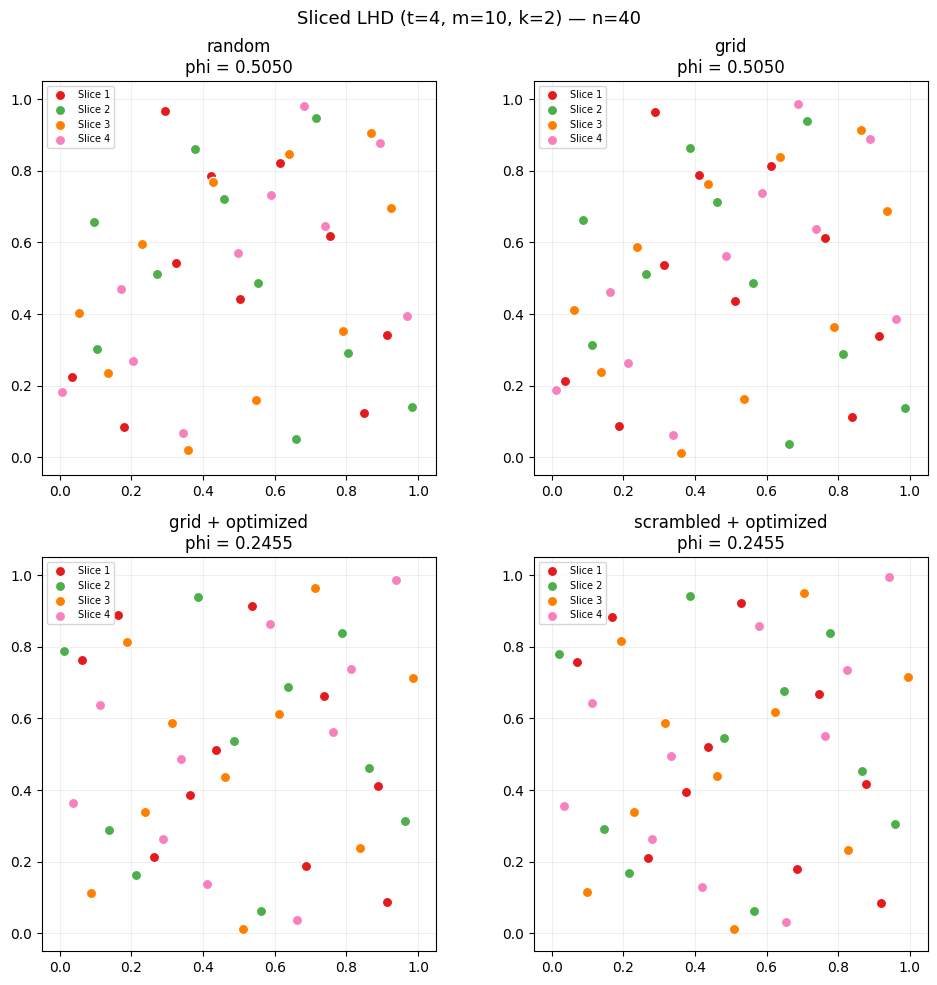

In [6]:
plot_scatter_grid(small_options, title="Sliced LHD (t=4, m=10, k=2) — n=40")

### Big Design — Statistics (n=160, k=3)

Scaling up to $n = 160$ runs ($t=4$ slices, $m=40$ per slice, $k=3$ dimensions). All four configurations are evaluated via:

- **$\phi$** — maximin criterion (lower = better spread); the objective that `maximinSLHD` optimises
- **LHS degree** — fraction of $n$ strata occupied per dimension; 1.0 means every stratum is covered exactly once (perfect LHD)
- **KS statistic** — Kolmogorov–Smirnov distance from $U(0,1)$ per column; lower = more uniform marginals; checked for the full design and separately for each slice
- **Star discrepancy** $D^*$ — maximum pointwise deviation of the empirical CDF from the product uniform; benchmark $\sqrt{k/n}$
- **Centered discrepancy** CD — weighted $L_2$ distance from the centered uniform; lower is better

In [7]:
t_big, m_big, k_big = 4, 40, 3
t0 = time.time()

result_big_rand      = build_random_result(t_big, m_big, k_big, seed=17, scramble=True)
result_big_rand_grid = build_random_result(t_big, m_big, k_big, seed=17, scramble=False)
result_big_grid_opt  = maximinSLHD(t=t_big, m=m_big, k=k_big, random_state=17,
                                   scramble=False, total_iter=200_000)
result_big_scram_opt = maximinSLHD(t=t_big, m=m_big, k=k_big, random_state=17,
                                   scramble=True, total_iter=200_000)
print(f"Elapsed: {time.time() - t0:.1f}s")

big_options = [
    {"label": "random",               "result": result_big_rand,      "color": "black", "ls": ":",  "lw": 1.5},
    {"label": "grid",                 "result": result_big_rand_grid, "color": "black", "ls": "-.", "lw": 1.2},
    {"label": "grid + optimized",     "result": result_big_grid_opt,  "color": "black", "ls": "--", "lw": 2.0},
    {"label": "scrambled + optimized","result": result_big_scram_opt, "color": "black", "ls": "-",  "lw": 2.0},
]

Elapsed: 63.9s


In [8]:
for opt in big_options:
    print_slhd_stats(opt["result"], opt["label"])
    print()

random  n=160  t=4  k=3
  valid=True  phi=0.0908  LHS_degree=1.0000
  KS_full  mean=0.0062  max=0.0062
  KS_slice mean=0.0246  max=0.0250
  D*=0.0470  CD=0.0246

grid  n=160  t=4  k=3
  valid=True  phi=0.0908  LHS_degree=1.0000
  KS_full  mean=0.0031  max=0.0031
  KS_slice mean=0.0219  max=0.0219
  D*=0.0480  CD=0.0243

grid + optimized  n=160  t=4  k=3
  valid=True  phi=0.0589  LHS_degree=1.0000
  KS_full  mean=0.0031  max=0.0031
  KS_slice mean=0.0219  max=0.0219
  D*=0.0403  CD=0.0268

scrambled + optimized  n=160  t=4  k=3
  valid=True  phi=0.0589  LHS_degree=1.0000
  KS_full  mean=0.0062  max=0.0062
  KS_slice mean=0.0248  max=0.0250
  D*=0.0401  CD=0.0272



In [9]:
rows = []
for opt in big_options:
    s = slhd_stats(opt["result"])
    rows.append({"method": opt["label"], **s})

df = pd.DataFrame(rows).set_index("method")
df[["phi", "lhs_degree", "ks_full_mean", "ks_full_max",
    "ks_slice_mean", "ks_slice_max", "d_star", "cd"]].round(4)

,phi,lhs_degree,ks_full_mean,ks_full_max,ks_slice_mean,ks_slice_max,d_star,cd
method,,,,,,,,
random,0.0908,1.0,0.0062,0.0062,0.0246,0.0250,0.0470,0.0246
grid,0.0908,1.0,0.0031,0.0031,0.0219,0.0219,0.0480,0.0243
grid + optimized,0.0589,1.0,0.0031,0.0031,0.0219,0.0219,0.0403,0.0268
scrambled + optimized,0.0589,1.0,0.0062,0.0062,0.0248,0.0250,0.0401,0.0272


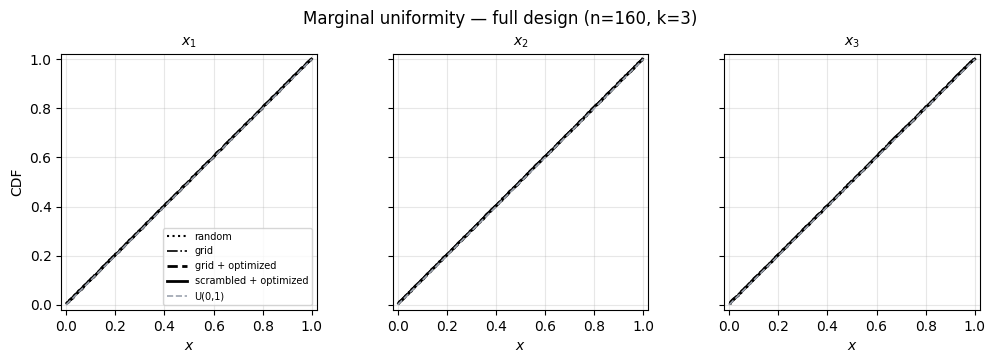

In [10]:
plot_marginal_uniformity_combined(
    big_options, k_big,
    title="Marginal uniformity — full design (n=160, k=3)"
)

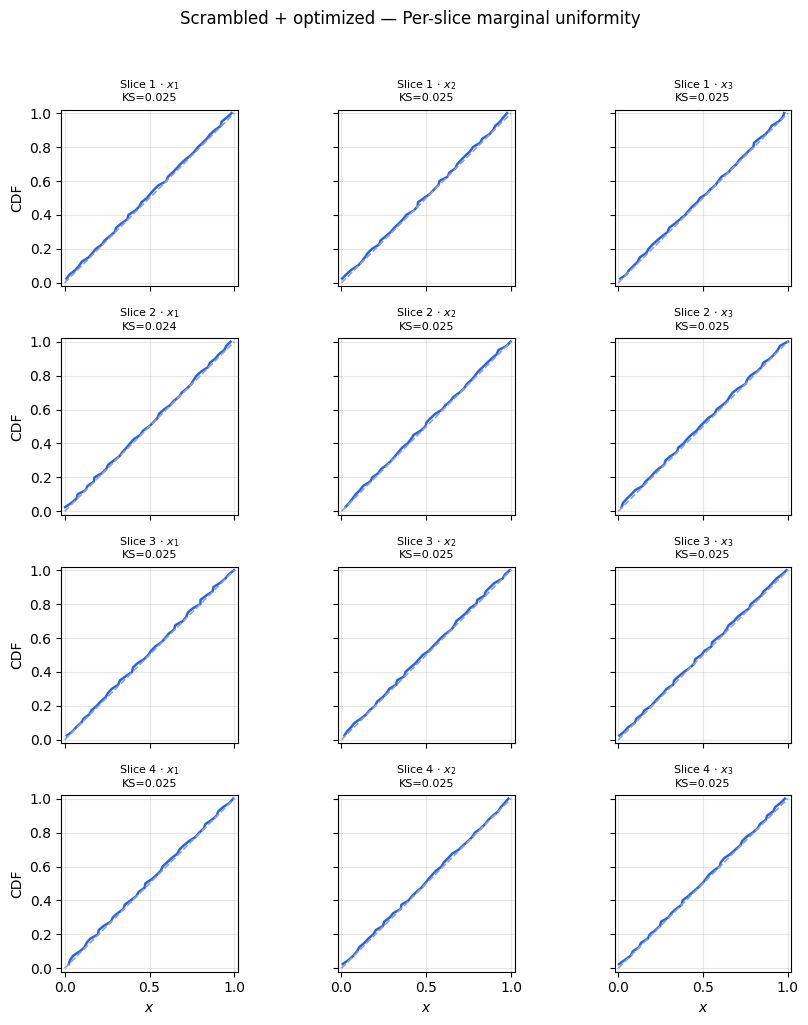

In [11]:
plot_per_slice_uniformity(result_big_scram_opt,
                           title_prefix="Scrambled + optimized — ")

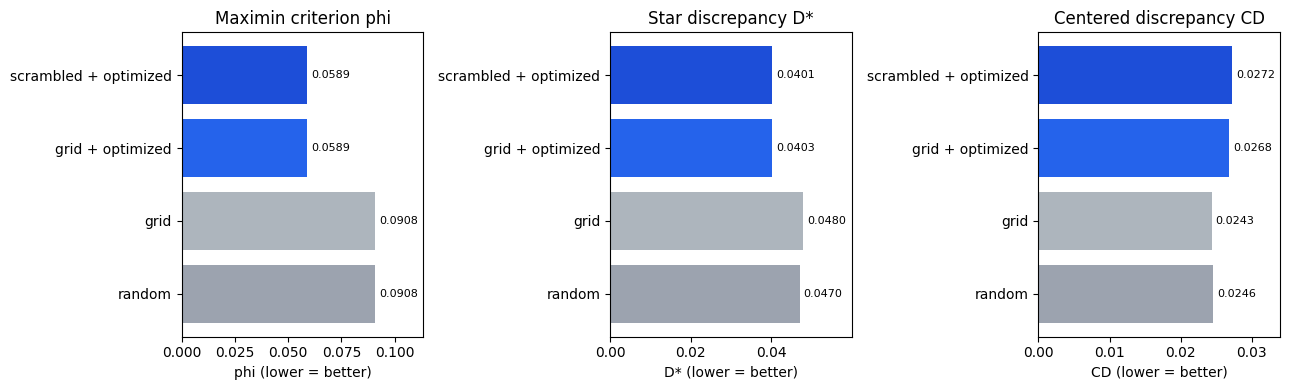

In [12]:
stats_list = [slhd_stats(opt["result"]) for opt in big_options]
labels = [opt["label"] for opt in big_options]
bar_colors = ["#9ca3af", "#adb5bd", "#2563eb", "#1d4ed8"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

phis   = [s["phi"]   for s in stats_list]
dstars = [s["d_star"] for s in stats_list]
cds    = [s["cd"]    for s in stats_list]

for ax, vals, xlabel, title in zip(
    axes,
    [phis, dstars, cds],
    ["phi (lower = better)", "D* (lower = better)", "CD (lower = better)"],
    ["Maximin criterion phi", "Star discrepancy D*", "Centered discrepancy CD"],
):
    bars = ax.barh(labels, vals, color=bar_colors)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_xlim(0, max(vals) * 1.25)

plt.tight_layout()
plt.show()